# Automotive industry sites

In [1]:
# Subscribe to api.insee.fr and get your credentials!
# Save your credentials with init_conn function :
# from pynsee.utils.init_conn import init_conn
 #init_conn(insee_key="my_insee_key", insee_secret="my_insee_secret")

# Beware : any change to the keys should be tested after having cleared the cache
# Please do : from pynsee.utils import clear_all_cache; clear_all_cache()"

In [2]:
import geopandas
import pandas as pd
import numpy as np
#%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib, descartes
import matplotlib.cm as cm

from pynsee import *

# get activity list
naf5 = get_activity_list('NAF5')

# search data in SIRENE database
df = search_sirene(variable = ["activitePrincipaleEtablissement"],
                   pattern = ['29.10Z'], kind = 'siret')

# keep only businesses with more then 100 employees
df = df.loc[df['effectifsMinEtablissement'] > 100]
df = df.reset_index(drop=True)

# find latitude and longitude of all businesses
df = df.get_location()

# make geodataframe
gdf = geopandas.GeoDataFrame(df)
gdf = gdf.reset_index(drop=True)
gdf = gdf.sort_values(by=['effectifsMinEtablissement'], ascending=False)


Getting legal entities: 100%|██████████| 12/12 [00:02<00:00,  4.36it/s]



!!! This function may return personal data, please check and
 comply with the legal framework relating to personal data protection !!!


Getting location: 100%|██████████| 47/47 [00:27<00:00,  1.69it/s]


In [3]:
geodataList =  get_geodata_list()
mapdep = get_geodata('ADMINEXPRESS-COG-CARTO.LATEST:departement')

# remove overseas departments
mapdep = mapdep[~mapdep['insee_dep'].isin(['971', '972', '973', '974', '976'])]

# conversion to geopandas df
mapdepgeo = geopandas.GeoDataFrame(mapdep).set_crs("EPSG:4326")
mapdepgeo.head()

Previously saved data used
/home/jovyan/.cache/insee/pynsee/2ac583be54e866b2b1b30fb0113c1fd0.csv
Set update=True to get the most up-to-date data
Previously saved data used
/home/jovyan/.cache/insee/pynsee/a28d68dc88fcd55fe62626ea25a1760a.csv
Set update=True to get the most up-to-date data


,id,nom_m,nom,insee_dep,insee_reg,geometry,bbox
0,DEPARTEM_FXX_00000000001,AIN,Ain,01,84,"MULTIPOLYGON (((4.79539 46.22007, 4.79676 46.2...","[4.72806849, 45.61108636, 6.17003068, 46.51991..."
1,DEPARTEM_FXX_00000000002,AISNE,Aisne,02,32,"MULTIPOLYGON (((3.12080 49.70572, 3.12052 49.7...","[2.95803556, 48.83720744, 4.25583685, 50.06949..."
2,DEPARTEM_FXX_00000000003,HAUTE-CORSE,Haute-Corse,2B,94,"MULTIPOLYGON (((9.47096 42.98463, 9.47126 42.9...","[8.57330539, 41.83218234, 9.56009361, 43.02769..."
3,DEPARTEM_FXX_00000000004,CORSE-DU-SUD,Corse-du-Sud,2A,94,"MULTIPOLYGON (((8.59798 41.88006, 8.59798 41.8...","[8.53468641, 41.33355569, 9.40803974, 42.3815338]"
4,DEPARTEM_FXX_00000000005,ALLIER,Allier,03,84,"MULTIPOLYGON (((2.53665 46.51970, 2.53717 46.5...","[2.2767858, 45.93072787, 4.00573657, 46.80428705]"


In [4]:
# make cleaned labels
conditions = [gdf['denominationUniteLegale'].str.contains('RENAULT SAS'),
              gdf['denominationUniteLegale'].str.contains('PSA AUTOMOBILES'),
              gdf['denominationUniteLegale'].str.contains('[^RENAULT SAS]|[^PSA AUTOMOBILES]')]
values = ['RENAULT SAS','PSA AUTOMOBILES', 'OTHER']
gdf['label'] = np.select(conditions, values)

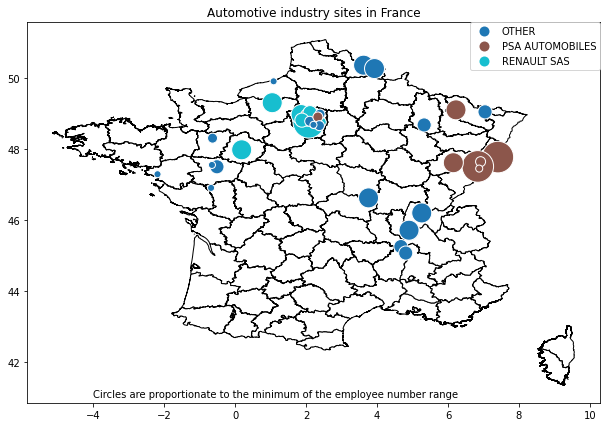

In [6]:
# annotation
txt = 'Circles are proportionate to the minimum of the employee number range'

#plot
ax = mapdepgeo.plot(color='white', edgecolor='black', figsize = (15,7))
plt.title('Automotive industry sites in France')
ax.annotate(txt, xy=(-4, 41), xytext=(-4, 41))
gdf.plot(ax=ax, 
         column = 'label',
         edgecolor='white',
         markersize=gdf.effectifsMinEtablissement/5,
         legend=True,
         legend_kwds={'bbox_to_anchor': (1,1),
                       'loc':1, 'borderaxespad': 0})
plt.show()